# Import Modules

In [2]:
import numpy as np
import pandas as pd 

from collections import Counter
from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  
import matplotlib.pyplot as plt

import seaborn as sns
import tensorflow as tf                   

from tensorflow.keras.initializers import he_normal                                     
from sklearn.model_selection import train_test_split       

from tensorflow.keras import regularizers                                             
from joblib import dump, load               
                                            
from sklearn.preprocessing import StandardScaler                                        

# Choosing lead time

In [3]:
lead_time = 1

# Import and split data

In [4]:
test = pd.read_csv("/home/users/mendrika/NCAST/Data/Dakar/data-test-dakar.csv")
train_full = pd.read_csv("/home/users/mendrika/NCAST/Data/Dakar/data-train-dakar.csv")

In [5]:
train_full.head(5)

,year,month,day,hour,minute,lat1,lat2,lat3,lon1,lon2,...,mask1,mask2,mask3,Cb_dakar_t0,Cb_dakar_t1,Cb_dakar_t2,Cb_dakar_t3,Cb_dakar_t4,Cb_dakar_t5,Cb_dakar_t6
0,2016,6,1,0,0,9.117052,5.968581,7.792680,-13.006007,-10.854632,...,1,0,0,0,0,0,0,0,0,0
1,2016,6,1,0,15,9.117916,23.603060,20.197540,-13.120132,-12.231322,...,1,0,0,0,0,0,0,0,0,0
2,2016,6,1,0,30,9.204070,21.798041,20.956625,-13.466753,-11.361980,...,1,0,0,0,0,0,0,0,0,0
3,2016,6,1,0,45,9.176445,9.089847,8.058894,-13.494109,-13.090345,...,1,1,0,0,0,0,0,0,0,0
4,2016,6,1,1,0,9.176445,8.753265,6.555203,-13.494109,-12.677598,...,1,1,0,0,0,0,0,0,0,0


In [6]:
val   = train_full[train_full["year"] == 2019].copy()
train = train_full[train_full["year"] != 2019].copy()

# Selecting Header

In [7]:
def choose_header(n, location, lead_time):
    """
    Generate header names for n closest storms.

    Returns:
        tuple of two lists:
            - input headers: year, month, day, hour, minute, lat1..n, lon1..n, wp1..n, size1..n, d1..n, mask1..n
            - target header: Cb_{location}_t{lead_time}
    """
    input_headers = ['year', 'month', 'day', 'hour', 'minute']
    
    for prefix in ['lat', 'lon', 'wp', 'size', 'd', 'mask']:
        input_headers.extend([f'{prefix}{i}' for i in range(1, n + 1)])
    
    target_header = f'Cb_{location}_t{lead_time}'
    
    return input_headers, target_header

In [8]:
input_headers, target_header = choose_header(3, "dakar", lead_time)

In [9]:
X_train = train[input_headers].copy()
X_val   = val[input_headers].copy()
X_test  = test[input_headers].copy()

y_train = train[target_header]
y_val   = val[target_header]
y_test  = test[target_header]

In [10]:
X_train

,year,month,day,hour,minute,lat1,lat2,lat3,lon1,lon2,...,wp3,size1,size2,size3,d1,d2,d3,mask1,mask2,mask3
0,2016,6,1,0,0,9.117052,5.968581,7.792680,-13.006007,-10.854632,...,0.0,1701,0,0,789.374126,1211.769889,1194.218543,1,0,0
1,2016,6,1,0,15,9.117916,23.603060,20.197540,-13.120132,-12.231322,...,0.0,1440,0,0,781.730084,1130.503040,1072.143181,1,0,0
2,2016,6,1,0,30,9.204070,21.798041,20.956625,-13.466753,-11.361980,...,0.0,1152,0,0,751.657623,1017.336340,1151.994820,1,0,0
3,2016,6,1,0,45,9.176445,9.089847,8.058894,-13.494109,-13.090345,...,0.0,684,171,0,752.464500,786.188758,1219.004327,1,1,0
4,2016,6,1,1,0,9.176445,8.753265,6.555203,-13.494109,-12.677598,...,0.0,738,189,0,752.464500,843.434783,1058.296346,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112185,2004,9,30,18,15,10.802887,22.877389,6.204820,-14.093934,-12.951414,...,0.0,171,0,0,568.506415,1024.162671,1151.990230,1,0,0
112186,2004,9,30,18,30,11.058403,19.986454,12.012427,-14.368961,-25.627664,...,0.0,558,0,0,527.487215,1045.285527,1047.915334,1,0,0
112187,2004,9,30,18,45,11.031423,20.732701,8.757046,-14.483280,-25.877825,...,0.0,855,0,0,522.049849,1113.502017,1001.958732,1,0,0
112188,2004,9,30,19,0,11.060403,20.853637,7.609722,-14.571967,-25.918951,...,0.0,1098,0,0,513.584774,1124.830630,1259.941383,1,0,0


In [16]:
y_train[y_train == 1].shape

(1171,)

# Exploratory data analysis

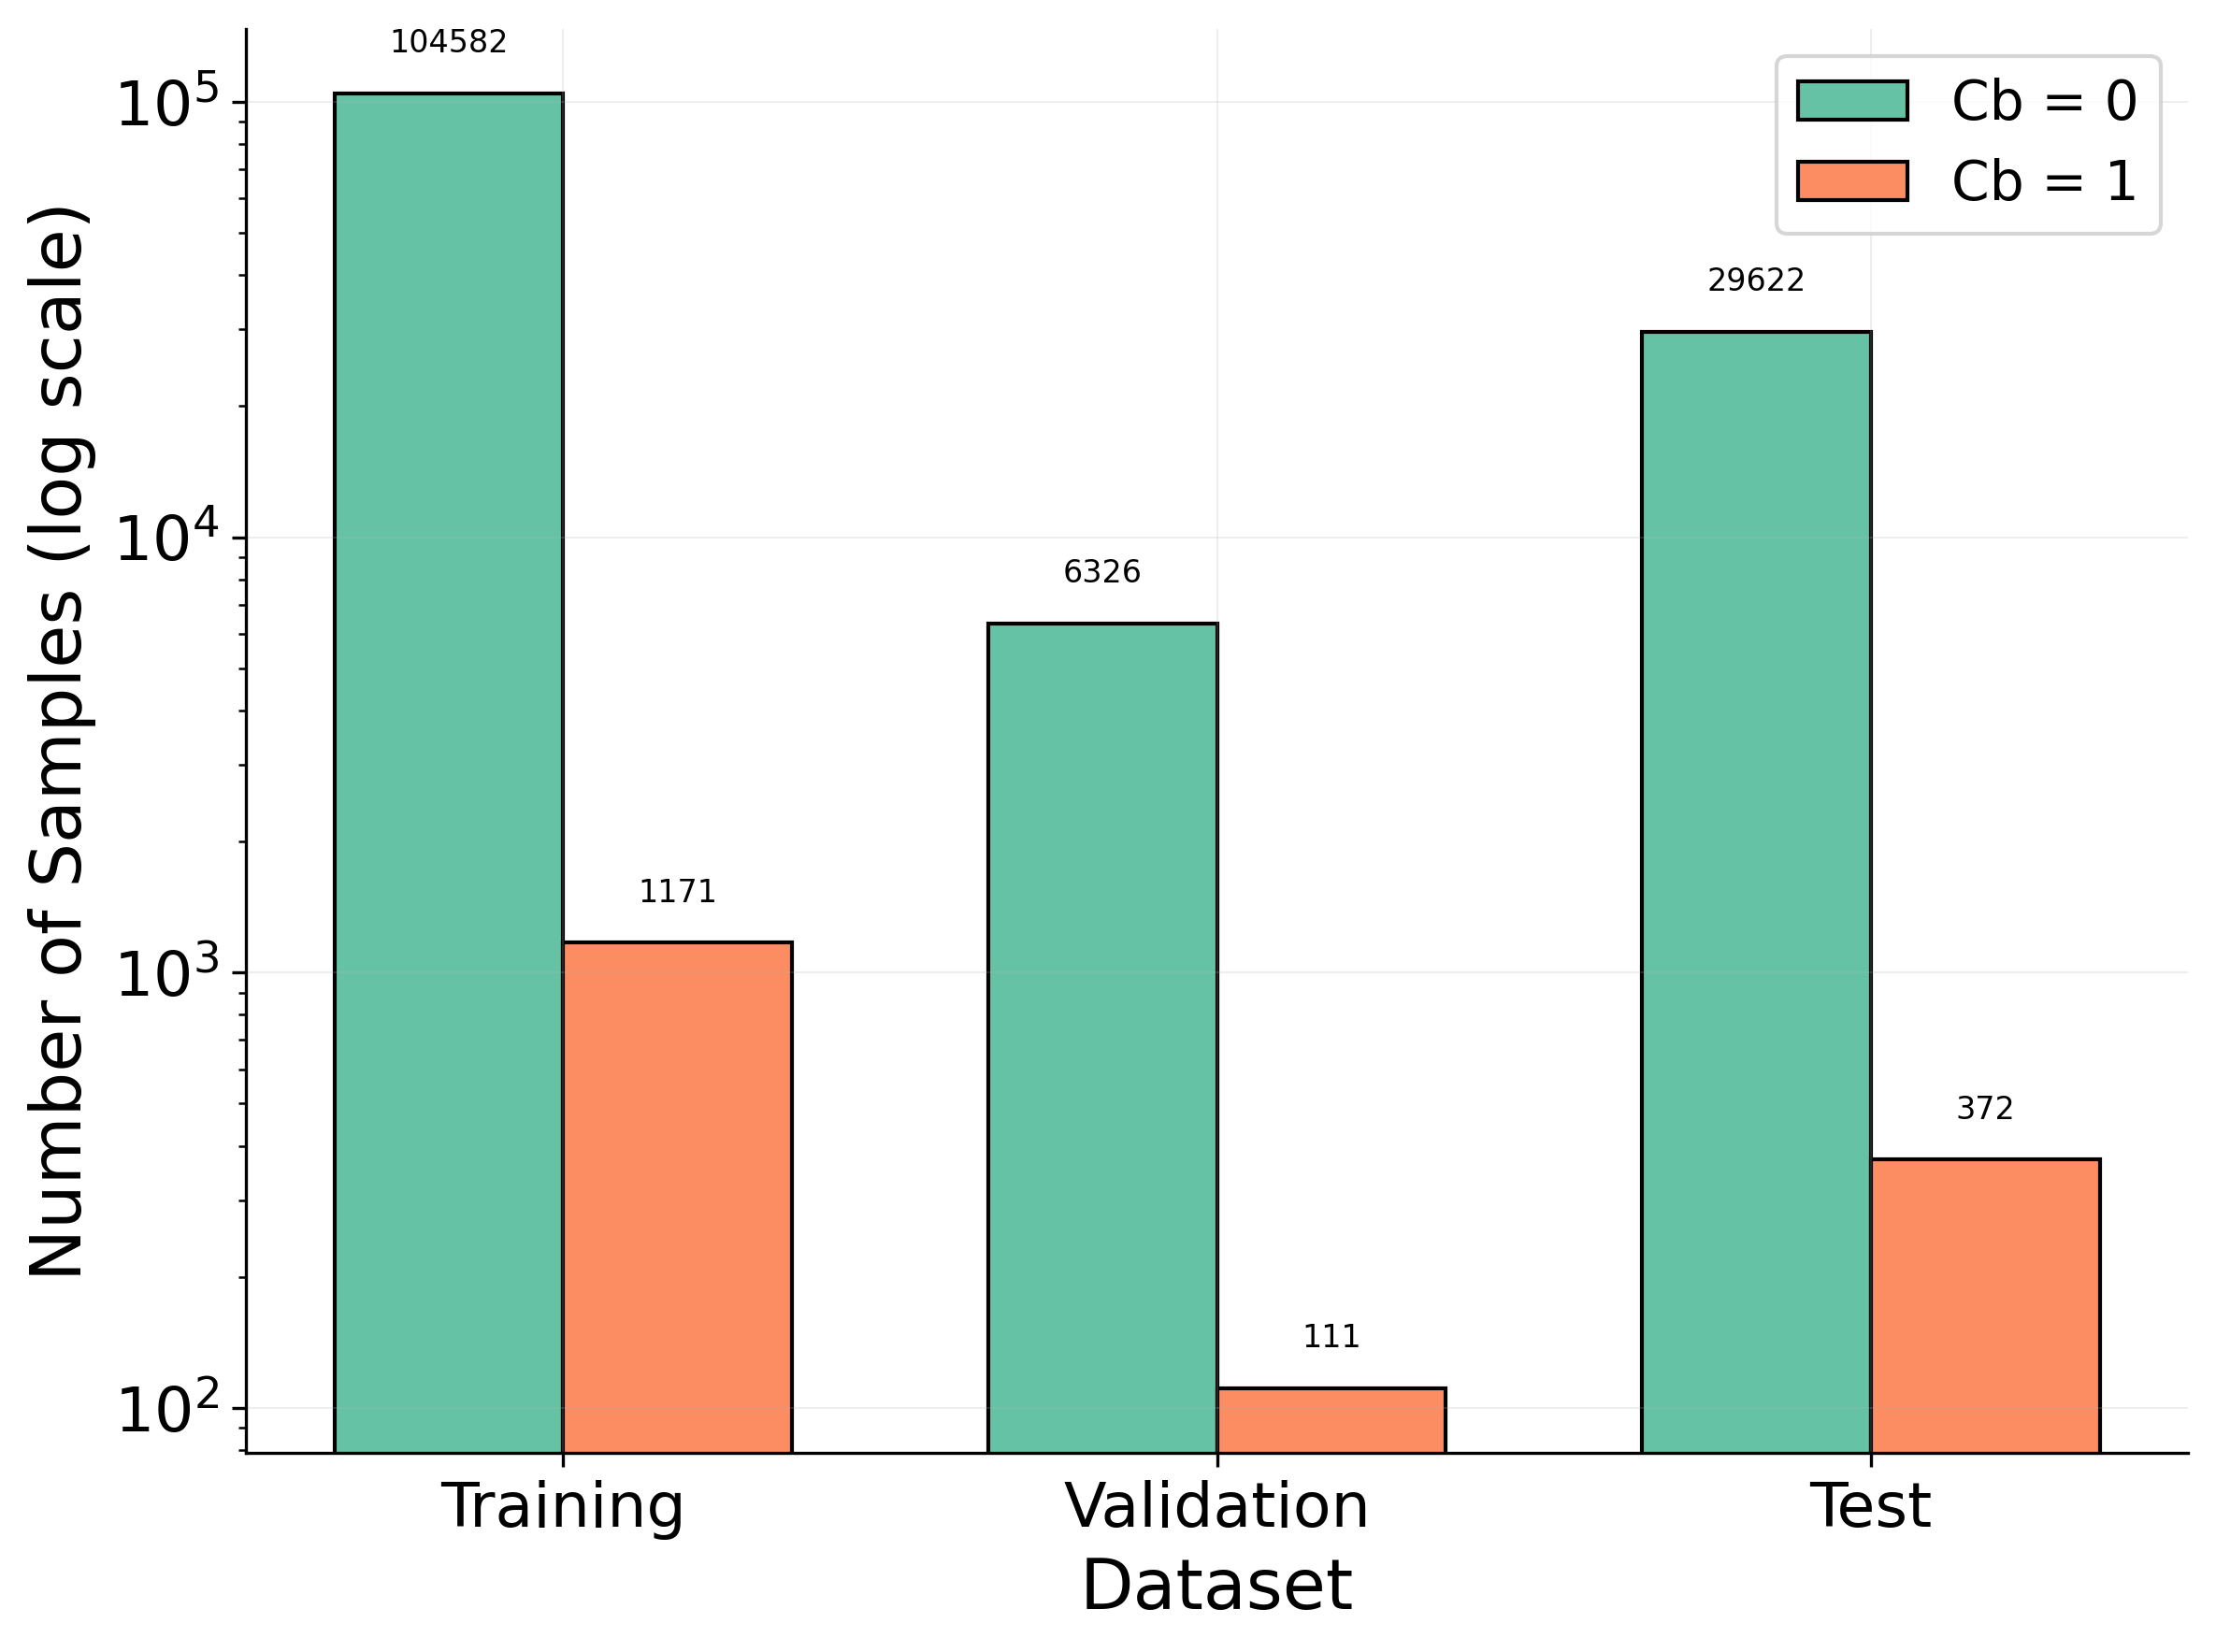

Train ratio: 0.011072971925146332
Val ratio: 0.01724405779089638
Test ratio: 0.01240248049609922


In [28]:
# Dataset types
types = ['Training', 'Validation', 'Test']

# Safe value counts (avoid KeyError if a class is missing)
no_core = [
    y_train.value_counts().get(0, 0),
    y_val.value_counts().get(0, 0),
    y_test.value_counts().get(0, 0)
]

core = [
    y_train.value_counts().get(1, 0),
    y_val.value_counts().get(1, 0),
    y_test.value_counts().get(1, 0)
]

x = np.arange(len(types))
width = 0.35
palette = sns.color_palette("Set2", 2)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars1 = ax.bar(x - width/2, no_core, width, label='Cb = 0', color=palette[0], edgecolor='black')
bars2 = ax.bar(x + width/2, core, width, label='Cb = 1', color=palette[1], edgecolor='black')

# Annotate bars with counts
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height * 1.2, f'{int(height)}',
                    ha='center', va='bottom', fontsize=8)

ax.set_yscale('log')

plt.xticks(x, types, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14)

plt.xlabel("Dataset", fontsize=18)
plt.ylabel("Number of Samples (log scale)", fontsize=18)
plt.grid(True, linewidth=0.1)

sns.despine()
plt.tight_layout()

plt.savefig("dataset_distribution_300.png", dpi=300, bbox_inches='tight')
plt.show()

# Print class ratios
print("Train ratio:", y_train.mean())
print("Val ratio:", y_val.mean())
print("Test ratio:", y_test.mean())

# Log transforming

In [31]:
cols_to_log = ['size1', 'size2', 'size3', 
               'wp1', 'wp2', 'wp3', 
               'd1', 'd2', 'd3']

for col in cols_to_log:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_val[col]   = np.log1p(X_val[col])
        X_test[col]  = np.log1p(X_test[col])

# Scaling

In [32]:
mask_cols = ['mask1', 'mask2', 'mask3']

# Columns grouped per core
core_groups = {
    1: ['lat1', 'lon1', 'wp1', 'size1', 'd1'],
    2: ['lat2', 'lon2', 'wp2', 'size2', 'd2'],
    3: ['lat3', 'lon3', 'wp3', 'size3', 'd3']
}

# Copy datasets
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

scalers = {}

for i, cols in core_groups.items():
    mask = X_train[f'mask{i}'] == 1
    
    scaler = StandardScaler()
    scaler.fit(X_train.loc[mask, cols])  # fit only on real cores
    
    scalers[i] = scaler
    
    # Apply to full dataset (including masked rows)
    X_train_scaled.loc[:, cols] = scaler.transform(X_train[cols])
    X_val_scaled.loc[:, cols]   = scaler.transform(X_val[cols])
    X_test_scaled.loc[:, cols]  = scaler.transform(X_test[cols])

# Model design

In [52]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer=he_normal()),
    tf.keras.layers.Dropout(0.2), 
    tf.keras.layers.Dense(16, activation='relu'),   
    tf.keras.layers.Dropout(0.2), 
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

classification_threshold = 0.1

METRICS = [                      
    tf.keras.metrics.Recall(name='recall', thresholds=classification_threshold),
    tf.keras.metrics.Precision(name='precision', thresholds=classification_threshold),
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.AUC(name='prc', curve='PR'), 
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=METRICS
)

In [53]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 64)                1536      
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_9 (Dense)             (None, 16)                1040      
                                                                 
 dropout_5 (Dropout)         (None, 16)                0         
                                                                 
 dense_10 (Dense)            (None, 8)                 136       
                                                                 
 dense_11 (Dense)            (None, 1)                 9         
                                                                 
Total params: 2721 (10.63 KB)
Trainable params: 2721 (

# Model training

In [54]:
X_train_scaled

,year,month,day,hour,minute,lat1,lat2,lat3,lon1,lon2,...,wp3,size1,size2,size3,d1,d2,d3,mask1,mask2,mask3
0,2016,6,1,0,0,-1.606468,-2.755466,-1.822706,1.179204,1.828370,...,-22.527858,0.303072,-4.855818,-4.886038,1.199335,2.117083,2.277766,1,0,0
1,2016,6,1,0,15,-1.606071,4.785366,3.198923,1.128921,1.260533,...,-22.527858,0.188286,-4.855818,-4.886038,1.185158,1.976080,2.010293,1,0,0
2,2016,6,1,0,30,-1.566406,4.013506,3.506209,0.976201,1.619107,...,-22.527858,0.034538,-4.855818,-4.886038,1.128005,1.761858,2.188474,1,0,0
3,2016,6,1,0,45,-1.579124,-1.420754,-1.714939,0.964148,0.906216,...,-22.527858,-0.324511,-1.208639,-4.886038,1.129568,1.238470,2.328723,1,1,0
4,2016,6,1,1,0,-1.579124,-1.564683,-2.323651,0.964148,1.076460,...,-22.527858,-0.272189,-1.138119,-4.886038,1.129568,1.381179,1.978051,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112185,2004,9,30,18,15,-0.830323,4.475055,-2.465490,0.699866,0.963520,...,-22.527858,-1.277410,-4.855818,-4.886038,0.721228,1.775440,2.188464,1,0,0
112186,2004,9,30,18,30,-0.712685,3.238838,-0.114504,0.578690,-4.264996,...,-22.527858,-0.464675,-4.855818,-4.886038,0.612180,1.816902,1.953601,1,0,0
112187,2004,9,30,18,45,-0.725106,3.557947,-1.432319,0.528322,-4.368179,...,-22.527858,-0.170845,-4.855818,-4.886038,0.597093,1.945303,1.842373,1,0,0
112188,2004,9,30,19,0,-0.711764,3.609661,-1.896769,0.489246,-4.385142,...,-22.527858,0.001462,-4.855818,-4.886038,0.573290,1.965863,2.410660,1,0,0


In [49]:
print(train.shape)
print(val.shape)
print(test.shape)

(105753, 30)
(6437, 30)
(29994, 30)


In [50]:
print("NaNs in X_train:", np.isnan(X_train_scaled).sum())
print("NaNs in X_val:", np.isnan(X_val_scaled).sum())
print("NaNs in X_test:", np.isnan(X_test_scaled).sum())

NaNs in X_train: year      0
month     0
day       0
hour      0
minute    0
lat1      0
lat2      0
lat3      0
lon1      0
lon2      0
lon3      0
wp1       0
wp2       0
wp3       0
size1     0
size2     0
size3     0
d1        0
d2        0
d3        0
mask1     0
mask2     0
mask3     0
dtype: int64
NaNs in X_val: year      0
month     0
day       0
hour      0
minute    0
lat1      0
lat2      0
lat3      0
lon1      0
lon2      0
lon3      0
wp1       0
wp2       0
wp3       0
size1     0
size2     0
size3     0
d1        0
d2        0
d3        0
mask1     0
mask2     0
mask3     0
dtype: int64
NaNs in X_test: year      0
month     0
day       0
hour      0
minute    0
lat1      0
lat2      0
lat3      0
lon1      0
lon2      0
lon3      0
wp1       0
wp2       0
wp3       0
size1     0
size2     0
size3     0
d1        0
d2        0
d3        0
mask1     0
mask2     0
mask3     0
dtype: int64


In [57]:
EPOCHS = 200
BATCH_SIZE = 64

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)


# train the model
model_history = model.fit(
    X_train_scaled.to_numpy().astype("float32"),
    y_train.astype("float32").to_numpy(),
    epochs=EPOCHS,
    callbacks=[early_stopping],
    batch_size=BATCH_SIZE,
    validation_data=(
        X_val_scaled.to_numpy().astype("float32"),
        y_val.astype("float32").to_numpy()
    ),
)

Epoch 1/200
   1/1653 [..............................] - ETA: 8s - loss: 0.6076 - recall: 0.0000e+00 - precision: 0.0000e+00 - auc: 0.3333 - prc: 0.0106

1653/1653 [==============================] - 2s 1ms/step - loss: 0.1282 - recall: 0.1452 - precision: 0.0116 - auc: 0.5151 - prc: 0.0114 - val_loss: 0.0904 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.8553 - val_prc: 0.0836
Epoch 2/200
1653/1653 [==============================] - 2s 1ms/step - loss: 0.0668 - recall: 0.0043 - precision: 0.0056 - auc: 0.5271 - prc: 0.0119 - val_loss: 0.0853 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.6271 - val_prc: 0.0467
Epoch 3/200
1653/1653 [==============================] - 2s 1ms/step - loss: 0.0640 - recall: 0.0034 - precision: 0.0092 - auc: 0.5582 - prc: 0.0134 - val_loss: 0.0816 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.8620 - val_prc: 0.1058
Epoch 4/200
1653/1653 [==============================] - 2s 1ms/step - loss: 0.0615 - recall: 0.0068 - precision: 0.0245 - auc: 0.6207 - prc: 0.0165 - val_loss: 0.0760 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_auc: 0.8902 - 

# Model evaluation

In [58]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    """
    Computes the optimal classification threshold using Youden's J statistic (sensitivity + specificity - 1).

    Parameters:
        fpr (array-like): False positive rates.
        tpr (array-like): True positive rates.
        thresholds (array-like): Thresholds corresponding to fpr and tpr.

    Returns:
        float: Threshold that maximises Youden's J statistic.
    """
    fpr = np.asarray(fpr)
    tpr = np.asarray(tpr)
    thresholds = np.asarray(thresholds)

    j_scores = tpr - fpr
    max_index = np.argmax(j_scores)
    return thresholds[max_index]


def plot_cm(y_true, y_pred_proba, threshold=0.5, labels=None, normalize=False):
    """
    Plots a confusion matrix using seaborn heatmap.

    Parameters:
        y_true (array-like): Ground truth binary labels.
        y_pred_proba (array-like): Predicted probabilities.
        threshold (float): Classification threshold to convert probabilities to binary predictions.
        labels (list): Optional list of class labels (e.g. ['Negative', 'Positive']).
        normalize (bool): Whether to normalize the confusion matrix.
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        fmt = '.2f'
    else:
        fmt = 'g'

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues_r', linewidths=0.5,
                xticklabels=labels or ['No core', 'Core'],
                yticklabels=labels or ['No core', 'Core'])
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title(f'Confusion Matrix (threshold = {threshold:.4f})')
    plt.tight_layout()
    plt.show()

202/202 [==============================] - 0s 660us/step
Optimal threshold from validation: 0.084


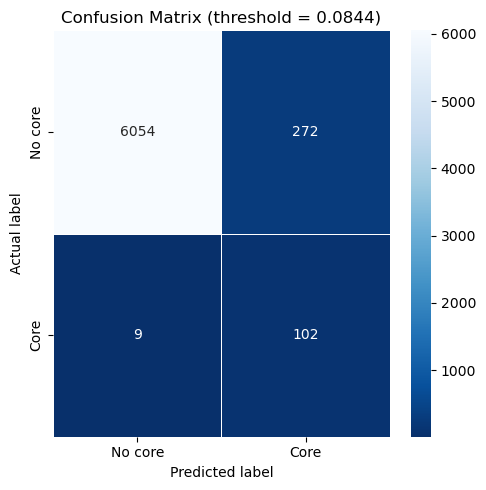

In [59]:
# Validation
y_val_pred = model.predict(X_val_scaled).flatten()
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
classification_threshold_val = cutoff_youdens_j(fpr, tpr, thresholds)
print(f"Optimal threshold from validation: {classification_threshold_val:.3f}")
plot_cm(y_val, y_val_pred, threshold=classification_threshold_val)


938/938 [==============================] - 1s 548us/step


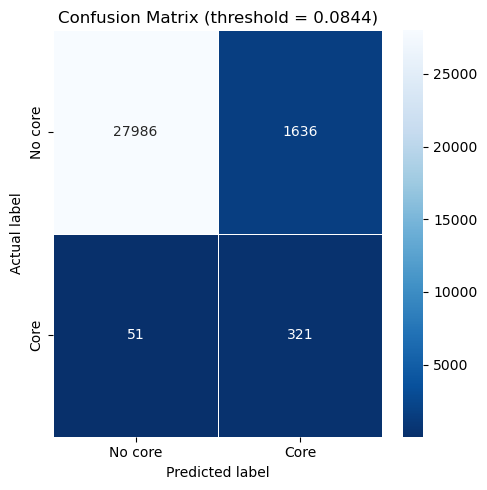

In [60]:
y_test_pred = model.predict(X_test_scaled).flatten()
plot_cm(y_test, y_test_pred, threshold=classification_threshold_val)

In [61]:
def reliability_curve(y_true, y_pred, bin_size=0.1, min_predictions_per_bin=50):
    """
    Computes the reliability curve (calibration curve) for a binary classifier.
    
    Parameters:
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred (array-like): Predicted probabilities (between 0 and 1).
        bin_size (float): Width of the bins to divide probability space.
        min_predictions_per_bin (int): Minimum number of predictions in a bin to be included.
        
    Returns:
        bin_centers (list): Midpoints of the bins used.
        bin_positive_rates (list): Observed frequency of positive class in each bin.
        bin_counts (list): Number of predictions in each bin.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0, 1 + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    bin_positive_rates = []
    bin_centers_output = []
    bin_counts = []

    for lower, upper, center in zip(bins[:-1], bins[1:], bin_centers):
        in_bin = (y_pred >= lower) & (y_pred < upper)
        count_in_bin = np.sum(in_bin)
        
        if count_in_bin >= min_predictions_per_bin:
            observed_rate = np.mean(y_true[in_bin])
            bin_positive_rates.append(round(observed_rate, 3))
            bin_centers_output.append(round(center, 3))
            bin_counts.append(count_in_bin)

    return bin_centers_output, bin_positive_rates, bin_counts

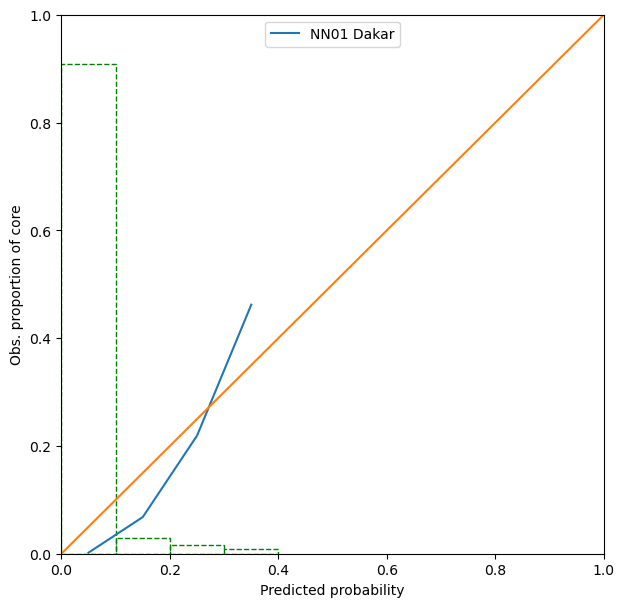

In [62]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_test_pred)

plt.figure(figsize=(7,7))
plt.plot(prob_pred, prob_true, label=f"NN0{lead_time} Dakar")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of core")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)

plt.legend(loc='upper center')
plt.show()

In [64]:
y_train_pred = model.predict(X_train_scaled)
auc_train = roc_auc_score(y_train, y_train_pred)
auc_val   = roc_auc_score(y_val, y_val_pred)
auc_test  = roc_auc_score(y_test, y_test_pred)

3305/3305 [==============================] - 2s 559us/step


In [65]:
def plot_roc(name, y_true, y_pred_proba, **kwargs):
    """
    Plots the ROC curve with hit rate vs false alarm rate (% scale).
    
    Parameters:
        name (str): Label for the curve (e.g., model name).
        y_true (array-like): Ground truth binary labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities (from model).
        **kwargs: Additional plotting keyword arguments (e.g. linestyle, color).
    """
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    
    plt.plot(100 * fpr, 100 * tpr, label=name, linewidth=1.5, **kwargs)
    plt.xlabel('False Alarm Rate [%]')
    plt.ylabel('Hit Rate [%]')
    plt.xlim([-1, 100])
    plt.ylim([0, 105])
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.legend(loc='lower right')

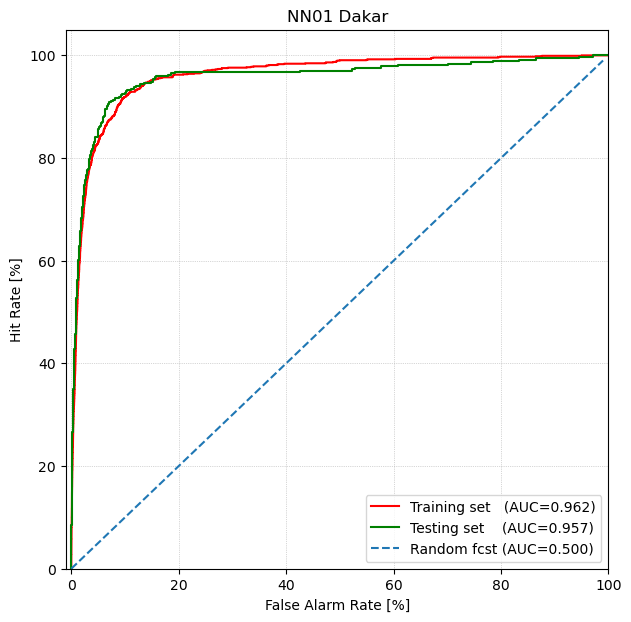

In [66]:
plt.figure(figsize=(7,7))
plot_roc(f"Training set   (AUC={auc_train:.3f})", y_train, y_train_pred, color="red")
plot_roc(f"Testing set    (AUC={auc_test:.3f})", y_test, y_test_pred, color='green')
plt.plot(range(0,100), range(0,100), label='Random fcst (AUC=0.500)', linestyle='--', linewidth=1.5)
plt.title(f"NN0{lead_time} Dakar")
plt.legend(loc='lower right');

# Saving the model

In [25]:
# dump(scaler, f'./model-dakar-t{lead_time}.pkl')
# model.save(f'./model-dakar-t{lead_time}.keras')